<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB0_Recapitulacion_Modulos1a4Sesion1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recapitulación integradora
## De los fundamentos (Módulo 1) a la estadística descriptiva (Módulo 4, Sesión 1)

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo



**Objetivo:** recorrer, de principio a fin, cómo se construye un proyecto de análisis estadístico aplicado a mantenimiento — desde que se define el problema de negocio hasta que se ajusta una distribución de probabilidad — usando exactamente lo que han visto en los módulos 1 a 4 (sesión 1).

## Mapa del proyecto

Un proyecto de análisis estadístico no empieza en el código — empieza en la pregunta de negocio. Este es el recorrido que ya hicieron, ordenado como un flujo CRISP-DM aplicado a mantenimiento:

| Paso | Pregunta que responde | Dónde lo vimos |
|---|---|---|
| 1. Entendimiento del negocio | ¿Qué decisión de mantenimiento queremos mejorar? | Módulo 1 |
| 2. Entendimiento y preparación de datos | ¿Tenemos datos confiables para responder? | Módulo 2 |
| 3. Extracción y exploración | ¿Qué nos dicen los datos a simple vista? | Módulo 3 |
| 4. Análisis estadístico | ¿Cómo se comporta cada activo, en números? | Módulo 4 · Sesión 1 |
| 5. (Siguiente) Confiabilidad y decisión | ¿Cuándo conviene dar mantenimiento? | Módulo 4 · Sesión 2 |

**Tiempo sugerido: 3 min.**

---
## Paso 1 · Entendimiento del negocio (Módulo 1)

Antes de tocar una sola línea de código, todo proyecto de mantenimiento predictivo parte de KPIs claros:

- **MTBF** (tiempo medio entre fallas) y **MTTR** (tiempo medio de reparación)
- **Disponibilidad** = MTBF / (MTBF + MTTR)
- Una **matriz de criticidad** para saber en qué activos concentrar el esfuerzo de análisis

**La pregunta de negocio que vamos a seguir en esta recapitulación:** *"¿qué tan predecible es el comportamiento de falla de cada equipo de la planta, y qué tipo de distribución lo describe mejor?"* — esta pregunta es la que conecta absolutamente todo lo que sigue.

---
## Paso 2 · Preparación y calidad de datos (Módulo 2)

Generamos el mismo dataset sintético de la flota de la planta metalúrgica que hemos usado desde el Módulo 2: 5 equipos, cada uno con un patrón de falla distinto (parámetro β de Weibull distinto, aunque eso todavía no lo "sabemos" formalmente — lo vamos a descubrir con estadística).

In [1]:
import numpy as np
import pandas as pd

# Flota de la planta metalúrgica — el mismo caso que hemos usado desde el Módulo 2.
EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()


,equipo,tbf_horas
0,Bomba Centrífuga,740.602455
1,Bomba Centrífuga,855.912043
2,Bomba Centrífuga,209.477435
3,Bomba Centrífuga,96.626541
4,Bomba Centrífuga,686.733096


**Chequeos de calidad que haríamos con datos reales** (aquí los datos ya vienen limpios porque son sintéticos, pero en un proyecto real este paso es obligatorio): NUNCA SALTAR ESTE PASO

In [2]:
# Nulos, duplicados y rango de valores — el mismo tipo de verificación del Módulo 2 tengo un equipo que fallo a las 2.1  horas y otro  hasta  las 10107.5 horas
print("Nulos por columna:\n", fallas.isna().sum())
print("\nRegistros duplicados:", fallas.duplicated().sum())
print("\nRango de tbf_horas: {:.1f} a {:.1f}".format(fallas["tbf_horas"].min(), fallas["tbf_horas"].max()))

Nulos por columna:
 equipo       0
tbf_horas    0
dtype: int64

Registros duplicados: 0

Rango de tbf_horas: 2.1 a 10107.5


---
## Paso 3 · Extracción y exploración con SQL (Módulo 3)

Con los datos ya preparados, los consultamos con SQL — igual que en el Módulo 3, usando DuckDB en memoria sobre el DataFrame `fallas`.

In [3]:
import duckdb

con = duckdb.connect()
con.register("fallas", fallas)
#having count  40  equipos  con mas de 40 fallas  son los unicos que apracen si le doy en having count mayor  a 60 solo aparece  un equipo el de 70
#select  selecciona las columnas
#count  agregacion

resumen_sql = con.execute("""
    SELECT
        equipo,
        COUNT(*)              AS n_fallas,
        ROUND(AVG(tbf_horas), 1)   AS tbf_promedio,
        ROUND(MIN(tbf_horas), 1)   AS tbf_min,
        ROUND(MAX(tbf_horas), 1)   AS tbf_max
    FROM fallas
    GROUP BY equipo
    HAVING COUNT(*) > 40
    ORDER BY tbf_promedio DESC
""").df()

resumen_sql

,equipo,n_fallas,tbf_promedio,tbf_min,tbf_max
0,Motor Eléctrico,55,1375.6,31.8,10107.5
1,Transportador de Banda,58,1024.3,39.6,4947.3
2,Ventilador Industrial,50,905.1,56.5,1969.1
3,Bomba Centrífuga,60,771.5,78.9,1617.4
4,Compresor de Aire,70,460.1,2.1,3259.5


**Lectura:** con un `GROUP BY` + `HAVING` —el mismo patrón del Módulo 3— ya filtramos a los equipos con suficientes fallas registradas para un análisis estadístico confiable, y tenemos un primer resumen numérico antes de pasar a estadística formal.

Y el EDA visual —también del Módulo 3— nos da la primera pista de la forma de los datos:

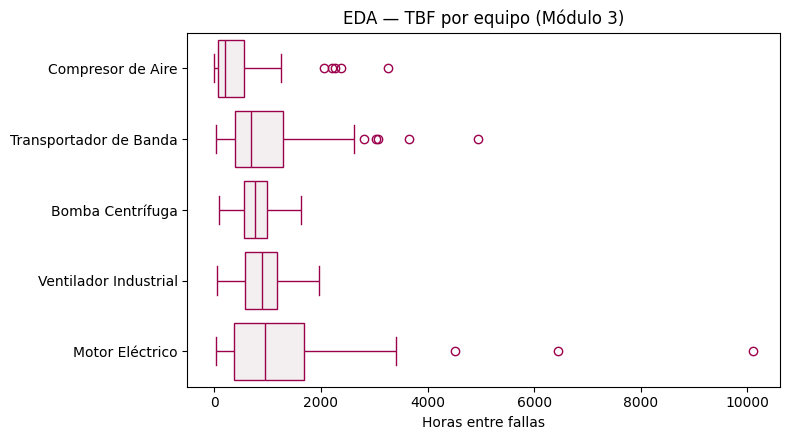

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=fallas, x="tbf_horas", y="equipo",
            order=fallas.groupby("equipo")["tbf_horas"].median().sort_values().index,
            color="#F4EEF1", linecolor="#9B004C")
plt.title("EDA — TBF por equipo (Módulo 3)")
plt.xlabel("Horas entre fallas")
plt.ylabel("")
plt.tight_layout()
plt.show()
#3 activos con outliers   EDA analisis exploratorio de datos

---
## Paso 4 · Estadística descriptiva y distribución de fallas (Módulo 4 · Sesión 1)

Aquí es donde estamos parados hoy. Tomamos un equipo —la **Bomba Centrífuga**— y aplicamos todo el flujo de la Sesión 1: describir, visualizar, ajustar y decidir.

In [ ]:
bomba = fallas[fallas["equipo"] == "Bomba Centrífuga"]["tbf_horas"]

from scipy import stats

media, mediana, std = bomba.mean(), bomba.median(), bomba.std()
iqr = bomba.quantile(0.75) - bomba.quantile(0.25)
asimetria, curtosis = stats.skew(bomba), stats.kurtosis(bomba)

print(f"Media:      {media:.1f} h")
print(f"Mediana:    {mediana:.1f} h")
print(f"Desv. Std:  {std:.1f} h")
print(f"IQR:        {iqr:.1f} h")
print(f"Asimetría:  {asimetria:.2f}")
print(f"Curtosis:   {curtosis:.2f}")

#cuando llega  a 1 la asimetria  y la curtosis  los datos  no estan balanceados

Media:      771.5 h
Mediana:    770.4 h
Desv. Std:  312.9 h
IQR:        423.1 h
Asimetría:  0.06
Curtosis:   -0.02


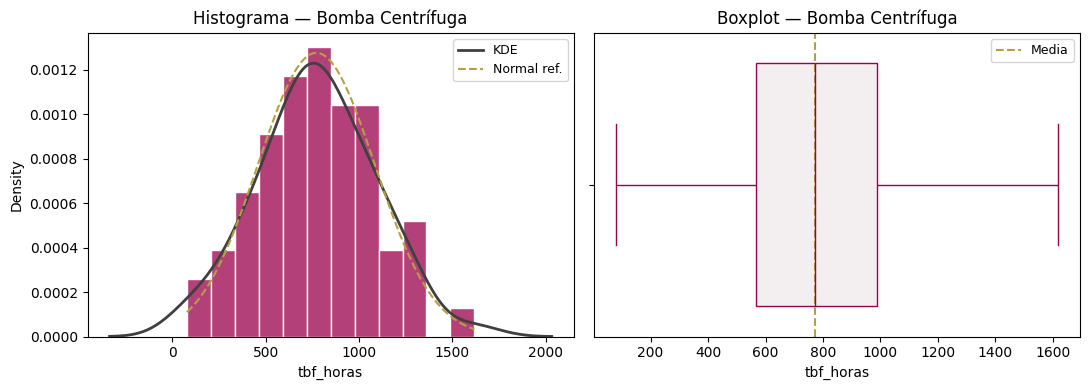

In [ ]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(bomba, bins=12, stat="density", color="#9B004C", edgecolor="white", ax=axes[0])
sns.kdeplot(bomba, color="#404040", linewidth=2, label="KDE", ax=axes[0])
x_ref = np.linspace(bomba.min(), bomba.max(), 200)
axes[0].plot(x_ref, norm.pdf(x_ref, media, std), color="#B5A042", linestyle="--", label="Normal ref.")
axes[0].set_title("Histograma — Bomba Centrífuga")
axes[0].legend(fontsize=9)

sns.boxplot(x=bomba, ax=axes[1], color="#F4EEF1", linecolor="#9B004C")
axes[1].axvline(media, color="#B5A042", linestyle="--", label="Media")
axes[1].set_title("Boxplot — Bomba Centrífuga")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
candidatas = {"Normal": stats.norm, "Exponencial": stats.expon, "Weibull": stats.weibull_min}

resultados = []
for nombre, dist in candidatas.items():
    params = dist.fit(bomba)
    ks_stat, ks_p = stats.kstest(bomba, dist.cdf, args=params)
    resultados.append({"distribución": nombre, "KS_stat": ks_stat, "KS_p_value": ks_p})

tabla = pd.DataFrame(resultados).sort_values("KS_stat")
tabla

#analisis KS nos dice que la normal le gana  a la weibull

,distribución,KS_stat,KS_p_value
0,Normal,0.042078,0.999780
2,Weibull,0.044849,0.999315
1,Exponencial,0.294243,0.000042


**Cierre del recorrido:** en cuatro pasos —negocio, datos, SQL/EDA, estadística— pasamos de "tenemos un problema de mantenimiento" a "tenemos evidencia estadística de qué distribución describe la falla de este equipo". Ese es exactamente el punto donde retomamos en la Sesión 2, para calcular confiabilidad y simular escenarios de riesgo con Weibull.
